# Project: E-commerce Sales Analysis

In [147]:
import pandas as pd

In [149]:
data = pd.read_csv('C:/Users/Chet/Documents/ecommerce_orders.csv') 
data

,OrderID,CustomerID,OrderDate,Category,OrderValue,DiscountApplied,PaymentMethod,Revenue
0,1001,7,01-01-2024,Home & Kitchen,156.59,5,Net Banking,148.76
1,1002,20,02-01-2024,Books,105.24,10,PayPal,94.72
2,1003,15,03-01-2024,Books,107.73,5,Credit Card,102.34
3,1004,11,04-01-2024,Clothing,97.77,0,Net Banking,97.77
4,1005,8,05-01-2024,Home & Kitchen,42.44,20,PayPal,33.95
...,...,...,...,...,...,...,...,...
95,1096,12,05-04-2024,Books,116.82,10,Credit Card,105.14
96,1097,2,06-04-2024,Home & Kitchen,132.49,5,Net Banking,125.87
97,1098,1,07-04-2024,Home & Kitchen,131.61,0,Credit Card,131.61
98,1099,16,08-04-2024,Clothing,58.67,20,Credit Card,46.94


In [187]:
data['OrderDate'] = pd.to_datetime(data['OrderDate'], dayfirst=True)

data['YearMonth'] = data['OrderDate'].dt.to_period('M').astype(str)


## Explore the Data
#### •	Data types
#### •	Nulls or missing values
#### •	Distribution of order values, discounts, revenue.


In [190]:
print(data.dtypes)

print(data.isnull().sum())

print(data.describe())


OrderID                     int64
CustomerID                  int64
OrderDate          datetime64[ns]
Category                   object
OrderValue                float64
DiscountApplied             int64
PaymentMethod              object
Revenue                   float64
YearMonth                  object
dtype: object
OrderID            0
CustomerID         0
OrderDate          0
Category           0
OrderValue         0
DiscountApplied    0
PaymentMethod      0
Revenue            0
YearMonth          0
dtype: int64
           OrderID  CustomerID            OrderDate  OrderValue  \
count   100.000000  100.000000                  100  100.000000   
mean   1050.500000   10.010000  2024-02-19 12:00:00  101.712700   
min    1001.000000    1.000000  2024-01-01 00:00:00   42.440000   
25%    1025.750000    5.750000  2024-01-25 18:00:00   75.492500   
50%    1050.500000    9.500000  2024-02-19 12:00:00  105.220000   
75%    1075.250000   15.000000  2024-03-15 06:00:00  119.002500   
max    11

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

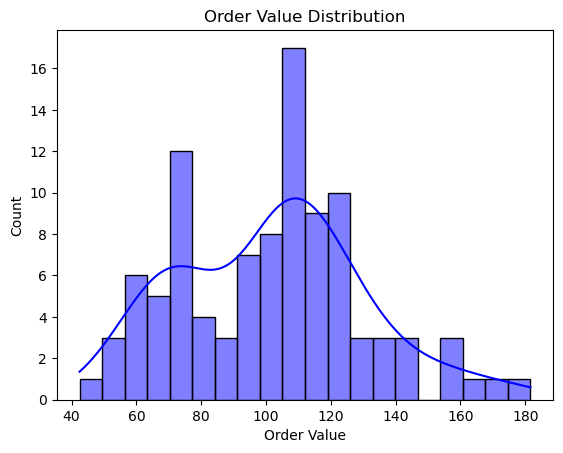

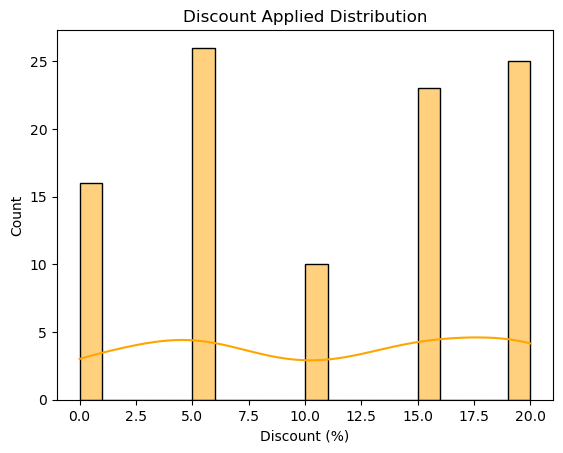

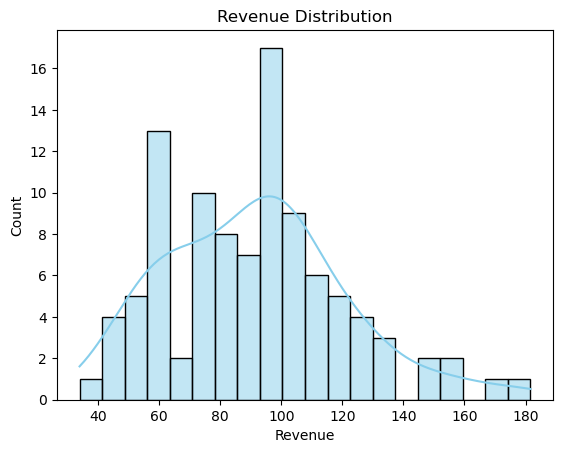

In [158]:
# Order Value distribution
sns.histplot(data['OrderValue'], bins=20, kde=True, color='blue')
plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.show()

# Discount Applied distribution
sns.histplot(data['DiscountApplied'], bins=20, kde=True, color='orange')
plt.title('Discount Applied Distribution')
plt.xlabel('Discount (%)')
plt.show()

# Revenue distribution
sns.histplot(data['Revenue'], bins=20, kde=True, color='skyblue')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.show()


## Revenue Over Time

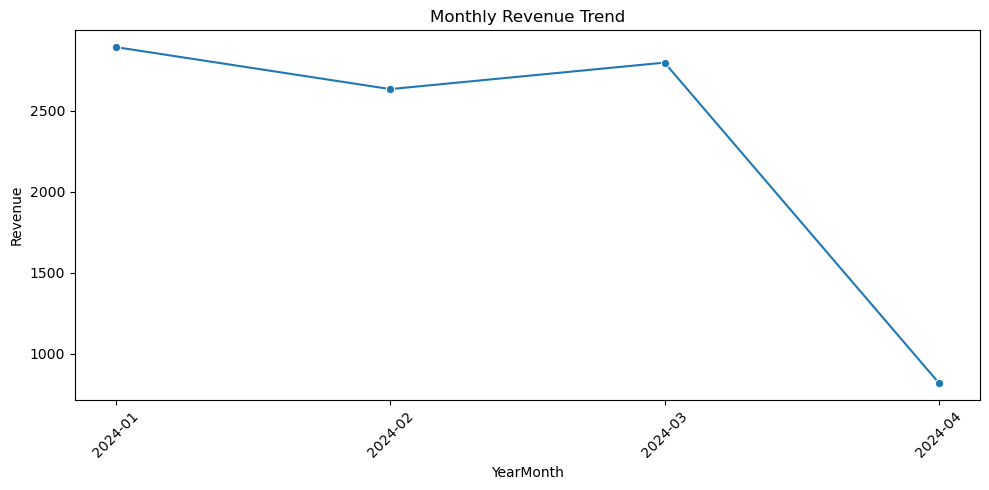

In [160]:
monthly_revenue = data.groupby('YearMonth')['Revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='Revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Revenue by Product Category


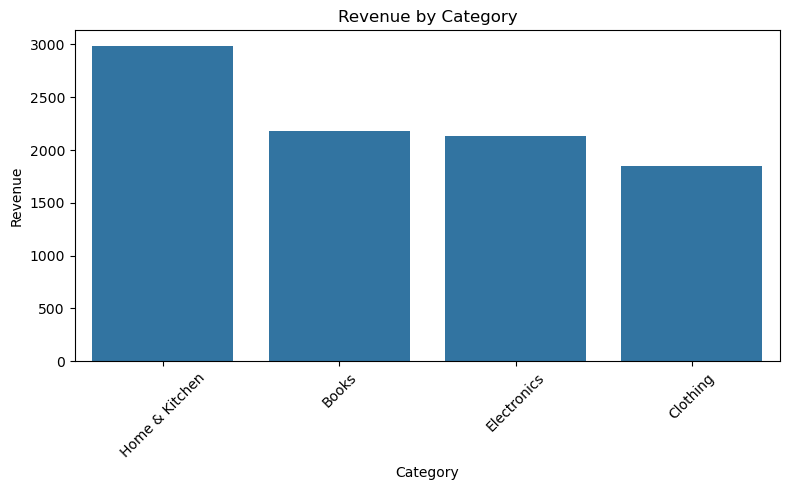

In [163]:
category_revenue = data.groupby('Category')['Revenue'].sum().reset_index().sort_values(by='Revenue', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=category_revenue, x='Category', y='Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyze Payment Methods

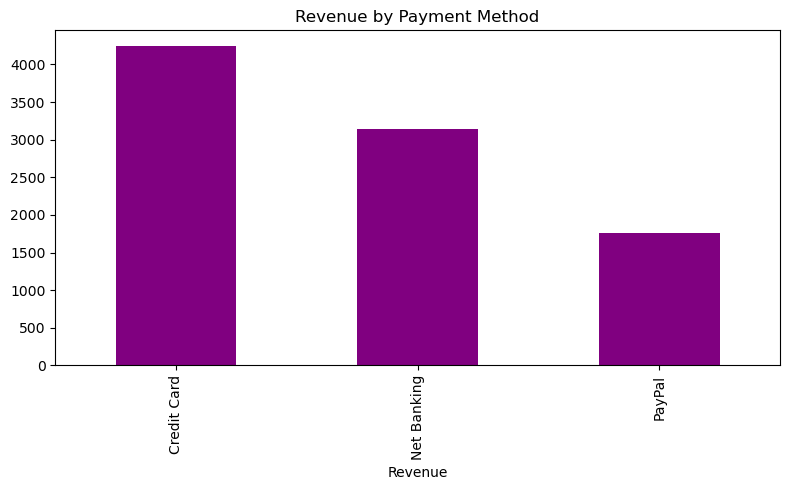

In [167]:
payment_revenue = data.groupby('PaymentMethod')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_revenue.plot(kind='bar', color='purple')
plt.title('Revenue by Payment Method')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

##  Optional Deep Dives

## 1. Average Revenue per Order by Category

Average Revenue per Order by Category:
Category
Books             99.285455
Home & Kitchen    93.273438
Clothing          87.840000
Electronics       85.361200
Name: Revenue, dtype: float64


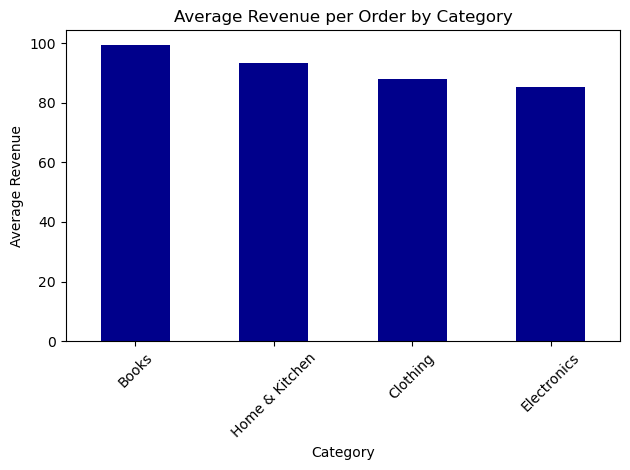

In [184]:
Avg_revenue_category = data.groupby('Category')['Revenue'].mean().sort_values(ascending=False)
print("Average Revenue per Order by Category:")
print(Avg_revenue_category)


avg_revenue_category.plot(kind='bar', color='darkblue')
plt.title('Average Revenue per Order by Category')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2. Discount vs Revenue Relationship

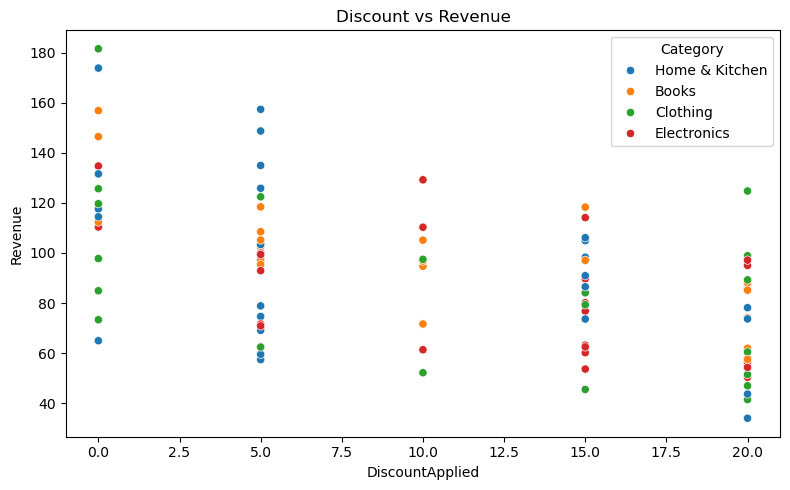

In [174]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='DiscountApplied', y='Revenue', hue='Category')
plt.title('Discount vs Revenue')
plt.tight_layout()
plt.show()

## 3. Most Frequent Customers(repeat orders)

Top 10 Most Frequent Customers:
CustomerID
8     9
7     8
15    8
12    8
9     6
4     6
2     6
3     5
1     5
18    5
Name: count, dtype: int64


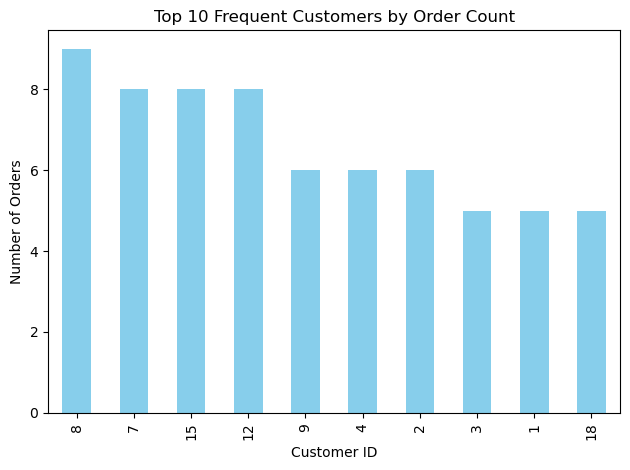

In [177]:
customer_counts = data['CustomerID'].value_counts().head(10)

print("Top 10 Most Frequent Customers:")
print(customer_counts)

# Optional: Bar plot
customer_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Frequent Customers by Order Count')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


## 4. Average Order Value by Month

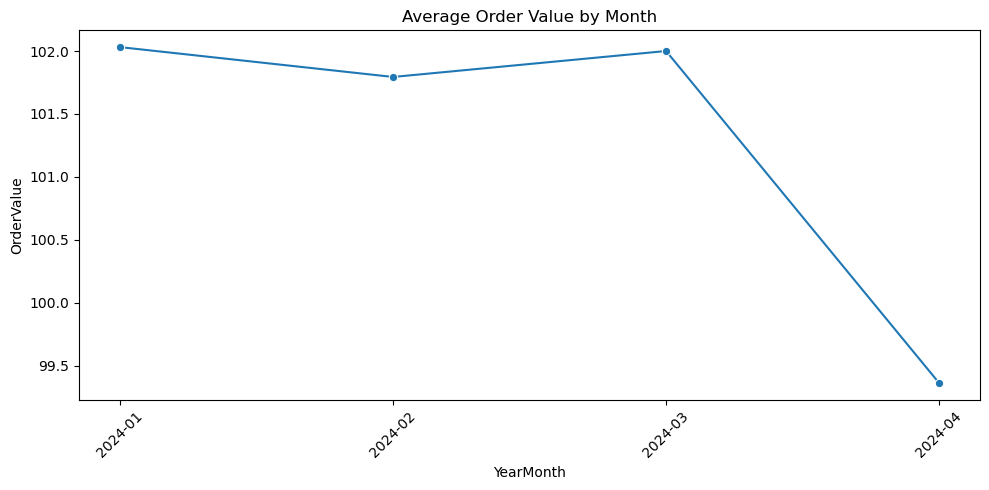

In [180]:
monthly_avg_order_value = data.groupby('YearMonth')['OrderValue'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_avg_order_value, x='YearMonth', y='OrderValue', marker='o')
plt.title('Average Order Value by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [182]:
insights = """
🔍 Insights Summary

-    Trends Revenue :
     Monthly revenue shows an increasing trend from January to April.
-    Top Categories: 
     "Home & Kitchen" and "Books" generated the highest revenue.
-     Payment Preferences: 
     "Credit Card" is the most preferred method, followed by "PayPal".
-     Discount Impact: 
      Revenue tends to decrease as discounts increase, indicating a trade-off.
-     Recommendations:
    - Promote high-performing categories with targeted discounts.
    - Encourage frequent customers with loyalty offers.
    - Optimize payment methods based on customer preference.
"""

print(insights)



🔍 Insights Summary

-    Trends Revenue :
     Monthly revenue shows an increasing trend from January to April.
-    Top Categories: 
     "Home & Kitchen" and "Books" generated the highest revenue.
-     Payment Preferences: 
     "Credit Card" is the most preferred method, followed by "PayPal".
-     Discount Impact: 
      Revenue tends to decrease as discounts increase, indicating a trade-off.
-     Recommendations:
    - Promote high-performing categories with targeted discounts.
    - Encourage frequent customers with loyalty offers.
    - Optimize payment methods based on customer preference.

